##1.importing needed libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

##2.cleaning the dataset from the nulls and exploring the data

In [ ]:
data = pd.read_csv('combined_scraped_cars_final.csv')

In [ ]:
data.isna().sum()

,0
URL,0
Brand,40
Model_Name,40
Year,40
Extension,72
Exterior_Color,40
Interior_Color,40
Origin,40
Fuel,40
Gear,40


In [ ]:
data.drop(['Engine_Type', 'Horsepower', 'Fuel_Tank', 'Doors', 'Keys', 'Link', 'URL'], axis=1, inplace=True)
# droping the unneeded columns and the columns with alot of nulls

In [ ]:
data.dropna(inplace=True) # droping the empty rows

In [ ]:
data

,Brand,Model_Name,Year,Extension,Exterior_Color,Interior_Color,Origin,Fuel,Gear,Cylinders,Condition,Engine_Size,Mileage,Drivetrain,Seats,Cash_Price
0,BYD,Qin Plus,2025.0,Premium,Grey,Beige,Saudi,Hybrid,Automatic,4 Cylinder,used,1.5,100 KM,FWD,5.0,68900.0
1,BYD,Song Plus,2024.0,Design,White,Beige,Saudi,Hybrid,CVT,4 Cylinder,new,1.5,0,FWD,5.0,89400.0
2,Changan,CS 75,2020.0,Full,Grey,Brown,Saudi,Gasoline,Automatic,4 Cylinder,used,1.8,92448 KM,FWD,5.0,50200.0
3,Mazda,6,2023.0,Skyactive G,Silver,Beige,Saudi,Gasoline,Automatic,4 Cylinder,used,2.5,27641 KM,FWD,5.0,78500.0
4,BYD,Song Plus,2024.0,Design,White,Beige,Saudi,Hybrid,CVT,4 Cylinder,new,1.5,0,FWD,5.0,89400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3611,Chevrolet,Silverado,2022.0,LT,Light gray,Beige,Saudi,Gasoline,Automatic,8 Cylinder,used,6.2,94261 KM,Double (4x4),5.0,146000.0
3612,Chevrolet,Tahoe,2023.0,LS,Silver,Beige,Saudi,Gasoline,Automatic,8 Cylinder,used,5.3,45555 KM,Double (4x4),7.0,184000.0
3613,Chevrolet,Groove,2023.0,Premier,Grey,Black,Saudi,Gasoline,CVT,4 Cylinder,used,1.5,80062 KM,FWD,5.0,52000.0
3614,BMW,X Series,2021.0,1 S Drive 20 i,Dark Blue,Black,Saudi,Gasoline,Automatic,4 Cylinder,used,2.0,45808 KM,FWD,5.0,87500.0


In [ ]:
data.isna().sum()

,0
Brand,0
Model_Name,0
Year,0
Extension,0
Exterior_Color,0
Interior_Color,0
Origin,0
Fuel,0
Gear,0
Cylinders,0


In [ ]:
data['Brand'].unique()

array(['BYD', 'Changan', 'Mazda', 'Hyundai', 'Nissan', 'Mitsubishi',
       'Kia', 'Chevrolet', 'Suzuki', 'Jeep', 'Honda', 'Toyota', 'Lexus',
       'Geely', 'MG', 'Ford', 'BMW', 'Mercedes', 'GMC'], dtype=object)

In [ ]:
len(data['Brand'].unique())

19

In [ ]:
data['Model_Name'].unique()

array(['Qin Plus', 'Song Plus', 'CS 75', '6', 'Alsvin', 'Eado Plus',
       'CS75 Plus', 'UNI V', 'CS35 Plus', 'UNI T', 'CS85', 'CS95',
       'Grand i10', 'Elantra', 'Accent', 'Kona', 'Tucson', 'Sonata',
       'Venue', 'Santafe', 'Azera', 'Creta', 'Sunny', 'Xterra', 'Xtrail',
       'Pathfinder', 'Altima', 'Kicks', 'Urvan', 'L200', 'Pajero',
       'Attrage', 'XPANDER', 'CX9', 'CX5', 'CX30', 'Sorento', 'Sportage',
       'Telluride', 'Seltos', 'Pegas', 'SONET', 'Cerato', 'K5', 'Rio',
       'Optima', 'Carnival', 'Groove', 'Suburban', 'Malibu', 'Captiva',
       'Tahoe', 'Cruze', 'Baleno', 'Dzire', 'Ciaz', 'Jimny', 'Fronx',
       'Wrangler', 'Compass', 'CRV', 'Accord', 'City', 'HR-V', 'Pilot',
       'Corolla', 'Yaris ', 'Fortuner', 'Haice', 'RAV4', 'Camry ',
       'Corolla Cross', 'Hilux', 'Innova', 'Raize', 'Veloz', 'Highlander',
       'Rush', 'Seal 7', 'UNI K', 'UNI-S', 'Hunter', 'Grand Creta',
       'Staria', 'Palisade', 'H1', 'STARGAZER', 'Patrol', 'Maxima',
       'EBRO (Fat

In [ ]:
len(data['Model_Name'].unique())

179

In [ ]:
data['Year'].unique()

array([2025., 2024., 2020., 2023., 2026., 2022., 2021., 2019., 2018.,
       2017., 2016.])

In [ ]:
len(data['Year'].unique())

11

In [ ]:
data['Exterior_Color'].unique()

array(['Grey ', 'White', 'Silver', 'Blue', 'Black', 'Burgundy', 'leaden',
       'Nardo Gray', 'Light Grey', 'Dark Blue', 'Dark leaden',
       'Light gray', 'Red', 'Brown', 'Baby blue', 'Beige', 'Golden',
       'light golden', 'Oil Green', 'Orange', 'Dark Brown ', 'Petrol',
       'Dark green', 'Light green', 'Green', 'Yellow', 'Bronze',
       'Dark Golden', 'Light Brown', 'Limon'], dtype=object)

In [ ]:
len(data['Exterior_Color'].unique())

30

In [ ]:
data['Interior_Color'].unique()

array(['Beige', 'Brown', 'Grey ', 'Black', 'Red', 'Camel ', 'Burgundy',
       'Blue', 'Light gray', 'Light Grey', 'Dark Blue', 'Green',
       'Light Brown', 'Dark Brown ', 'leaden', 'White', 'Bronze',
       'another_color', 'Dark leaden'], dtype=object)

In [ ]:
len(data['Interior_Color'].unique())

19

In [ ]:
data['Origin'].unique()

array(['Saudi', 'GCC', 'Other'], dtype=object)

In [ ]:
data['Fuel'].unique()

array(['Hybrid', 'Gasoline', 'Diesel'], dtype=object)

In [ ]:
data['Gear'].unique()

array(['Automatic', 'CVT', 'Manual'], dtype=object)

In [ ]:
data['Condition'].unique()

array(['used', 'new'], dtype=object)

In [ ]:
data['Extension'].unique()

array(['Premium', 'Design', 'Full', 'Skyactive G', 'Full Option', 'Basic',
       'Smart', 'Elite', 'Limited', 'Platinum', 'Fleet', 'GL',
       'Smart China', 'SMART', 'MID', 'Comfort', 'GL PANORAMA', 'GLS',
       'Smart Plus', 'Mid', 'COMFORT+', 'Comfort ', 'Grand', 'BSE',
       'Smart Panorama', 'Comfort (Two Tone)', 'GLS Smart', 'Classic',
       'SE', 'SV Comfort', 'Classic-comfort', 'SV', 'S 7 Seats', 'SL',
       'S', 'S 5 Seats', 'NV350', 'SV Plus', 'SR', 'S New Shape',
       'DC 4x4', 'DC 4x2 Diesel', 'Double Cap', 'DC 4x2', 'DC 4x4 Diesel',
       'GLS 3Doors', 'L', 'GLS 4Doors', 'HL', 'Skyactiv G', 'Signature',
       'Core', 'LX', 'EX', 'LX2', 'L - GLS TOP', 'K3', 'LT', 'LS', 'GLX',
       'GL5MT', 'Sport', 'DX', 'LX Sport', 'XLI', 'Y', 'GX2 4x4',
       'بضاعة سقف عالي', 'LE', 'LE HEV', 'GX2 4x2', 'GL DSL', 'GL2', 'VX',
       'Y Plus', 'XLE', 'XLI Executive', 'XLE HEV', 'YX', 'GL HEV',
       'LIMITED', 'E HEV', 'GX', 'XLI Executive Moonroof', 'GLE',
       'Grande', '

In [ ]:
len(data['Extension'].unique())

319

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3543 entries, 0 to 3615
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3543 non-null   object 
 1   Model_Name      3543 non-null   object 
 2   Year            3543 non-null   float64
 3   Extension       3543 non-null   object 
 4   Exterior_Color  3543 non-null   object 
 5   Interior_Color  3543 non-null   object 
 6   Origin          3543 non-null   object 
 7   Fuel            3543 non-null   object 
 8   Gear            3543 non-null   object 
 9   Cylinders       3543 non-null   object 
 10  Condition       3543 non-null   object 
 11  Engine_Size     3543 non-null   float64
 12  Mileage         3543 non-null   object 
 13  Drivetrain      3543 non-null   object 
 14  Seats           3543 non-null   float64
 15  Cash_Price      3543 non-null   float64
dtypes: float64(4), object(12)
memory usage: 470.6+ KB


In [ ]:
# --Processing the Extension column

def master_extension_cleaner(text):
    # Standardize the text: lower case, remove tabs and extra spaces
    text = str(text).lower().replace('\t', ' ').strip()

    # --- 1. Performance & Sport (High Priority) ---
    sport_keywords = ['sport', 'rs', 'gt', 'performance', 'amg', '63', 'f-sport', 'f sport', 'n line', 'srt', 'skyactive g', 'skyactiv']
    if any(word in text for word in sport_keywords):
        return 'Sport/Performance'

    # --- 2. Offroad & 4x4 (Functional Priority) ---
    offroad_keywords = ['4x4', '4wd', 'double', 'sahara', 'unlimited', 'willys', 'jk', 'z71', 'at4', 'adventure', 'txl', 'gxr', 'vxr', 'gx', 'fj cruiser', 'جي كي']
    if any(word in text for word in offroad_keywords):
        return 'Offroad/4x4'

    # --- 3. Hybrid & Electric Technology ---
    if any(word in text for word in ['hybrid', 'hev', 'phev', 'h ']):
        return 'Hybrid'

    # --- 4. Full Option & Luxury Trims ---
    full_keywords = ['premium', 'full', 'elite', 'limited', 'platinum', 'signature', 'royal', 'vip',
                     'calligraphy', 'titanium', 'prestige', 'vx', 'sl', 'le', 'grande', 'diamond',
                     'black ed', 'grand touring', 'high line', 'ليمتد', 'فل']
    if any(word in text for word in full_keywords):
        return 'Full Option'

    # --- 5. Mid Option & Comfort Trims ---
    mid_keywords = ['smart', 'mid', 'comfort', 'classic', 'se', 'sv', 'sr', 'ex', 'gle', 'gls',
                    'sel', 'trend', 'exclusive', 'design', 'hl', 'semi']
    if any(word in text for word in mid_keywords):
        return 'Mid Option'

    # --- 6. Standard & Economy & Commercial ---
    # Includes cargo, van, and basic work trims
    std_keywords = ['basic', 'fleet', 'gl', 'bse', 's', 'l', 'core', 'lx', 'ls', 'dx', 'xli', 'y',
                    'base', 'std', 'xe', 'xl', 'dlx', 'cargo', 'van', 'بضاعة', 'ثلاجة', 'ركاب', 'fleet']
    if any(word in text for word in std_keywords):
        return 'Standard'

    # --- 7. Specific Luxury/Engine Codes (e.g., 350, 500, 730li) ---
    # We keep these as they are high-value identifiers for Lexus, Mercedes, BMW
    # Logic: If it contains numbers and is short, keep it.
    if re.search(r'\d', text) and len(text) < 8:
        return text.upper()

    return 'Other'

# --- Apply the Master Cleaner ---
data['Extension_Clean'] = data['Extension'].apply(master_extension_cleaner)

# Check the new distribution
print("📊 Refined Distribution of Extensions:")
print(data['Extension_Clean'].value_counts())

📊 Refined Distribution of Extensions:
Extension_Clean
Standard             1281
Mid Option            827
Full Option           791
Other                 193
Sport/Performance     140
Offroad/4x4           125
Hybrid                 92
520I                   20
200                    17
450                     8
250                     7
300                     7
350                     5
735I                    4
K7                      3
DC 4X2                  3
600                     3
420I                    2
NV350                   2
COM 4*4                 2
350 DD                  2
K3                      1
450 H                   1
300 H                   1
GRADE 3                 1
200T                    1
TX2                     1
500                     1
5 M                     1
218I                    1
Name: count, dtype: int64


In [ ]:
data['Extension_Clean'].unique()

array(['Full Option', 'Mid Option', 'Sport/Performance', 'Standard',
       'Other', 'NV350', 'Offroad/4x4', 'DC 4X2', 'K3', 'Hybrid',
       'GRADE 3', '350', '300 H', '450 H', '250', '600', '350 DD', '300',
       '200T', 'K7', 'TX2', '520I', 'COM 4*4', '450', '200', '500',
       '420I', '735I', '5 M', '218I'], dtype=object)

In [ ]:
len(data['Extension_Clean'].unique())

30

In [ ]:
data.drop('Extension', axis=1, inplace=True)

In [ ]:
# --- 1. Clean the 'Mileage' column ---
# Convert values to string, remove ' KM' unit (case-insensitive) and strip commas for numerical processing
data['Mileage'] = data['Mileage'].astype(str).str.replace(' KM', '', case=False).str.replace(',', '')
# Convert cleaned strings to numeric floats; 'coerce' handles errors by setting them to NaN
data['Mileage'] = pd.to_numeric(data['Mileage'], errors='coerce')

# --- 2. Clean the 'Cylinders' column ---
# Apply a Regular Expression (Regex) to extract only the digits from text (e.g., "4 Cylinder" becomes "4")
data['Cylinders'] = data['Cylinders'].astype(str).str.extract('(\d+)')
# Convert the extracted string representation of digits into a numeric format
data['Cylinders'] = pd.to_numeric(data['Cylinders'], errors='coerce')

# --- 3. Verification ---
# Display the data types to ensure 'Mileage' and 'Cylinders' are now numerical (float or int)
print(data[['Mileage', 'Cylinders']].dtypes)
# Preview the top rows to confirm that units and extra text have been successfully removed
print(data[['Mileage', 'Cylinders']].head())

Mileage      float64
Cylinders      int64
dtype: object
   Mileage  Cylinders
0    100.0          4
1      0.0          4
2  92448.0          4
3  27641.0          4
4      0.0          4


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_16708/3533790742.py:9: SyntaxWarning: invalid escape sequence '\d'
  data['Cylinders'] = data['Cylinders'].astype(str).str.extract('(\d+)')


In [ ]:
data.describe()

,Year,Cylinders,Engine_Size,Mileage,Seats,Cash_Price
count,3543.000000,3543.000000,3543.000000,3541.000000,3543.000000,3543.000000
mean,2023.371437,4.283093,2.072791,62023.039254,5.378493,85701.952018
std,1.802438,0.960992,0.916003,56621.221205,0.931814,60591.948141
min,2016.000000,3.000000,1.000000,0.000000,2.000000,21800.000000
25%,2022.000000,4.000000,1.500000,0.000000,5.000000,46700.000000
50%,2023.000000,4.000000,1.600000,60772.000000,5.000000,68400.000000
75%,2025.000000,4.000000,2.500000,102490.000000,5.000000,102500.000000
max,2026.000000,8.000000,6.200000,883334.000000,13.000000,555000.000000


In [ ]:
data.isna().sum()

,0
Brand,0
Model_Name,0
Year,0
Exterior_Color,0
Interior_Color,0
Origin,0
Fuel,0
Gear,0
Cylinders,0
Condition,0


In [ ]:
data.dropna(inplace=True) # there are few nulls could apper so we just drop them due to the Milage column processing

#3.determing outliers

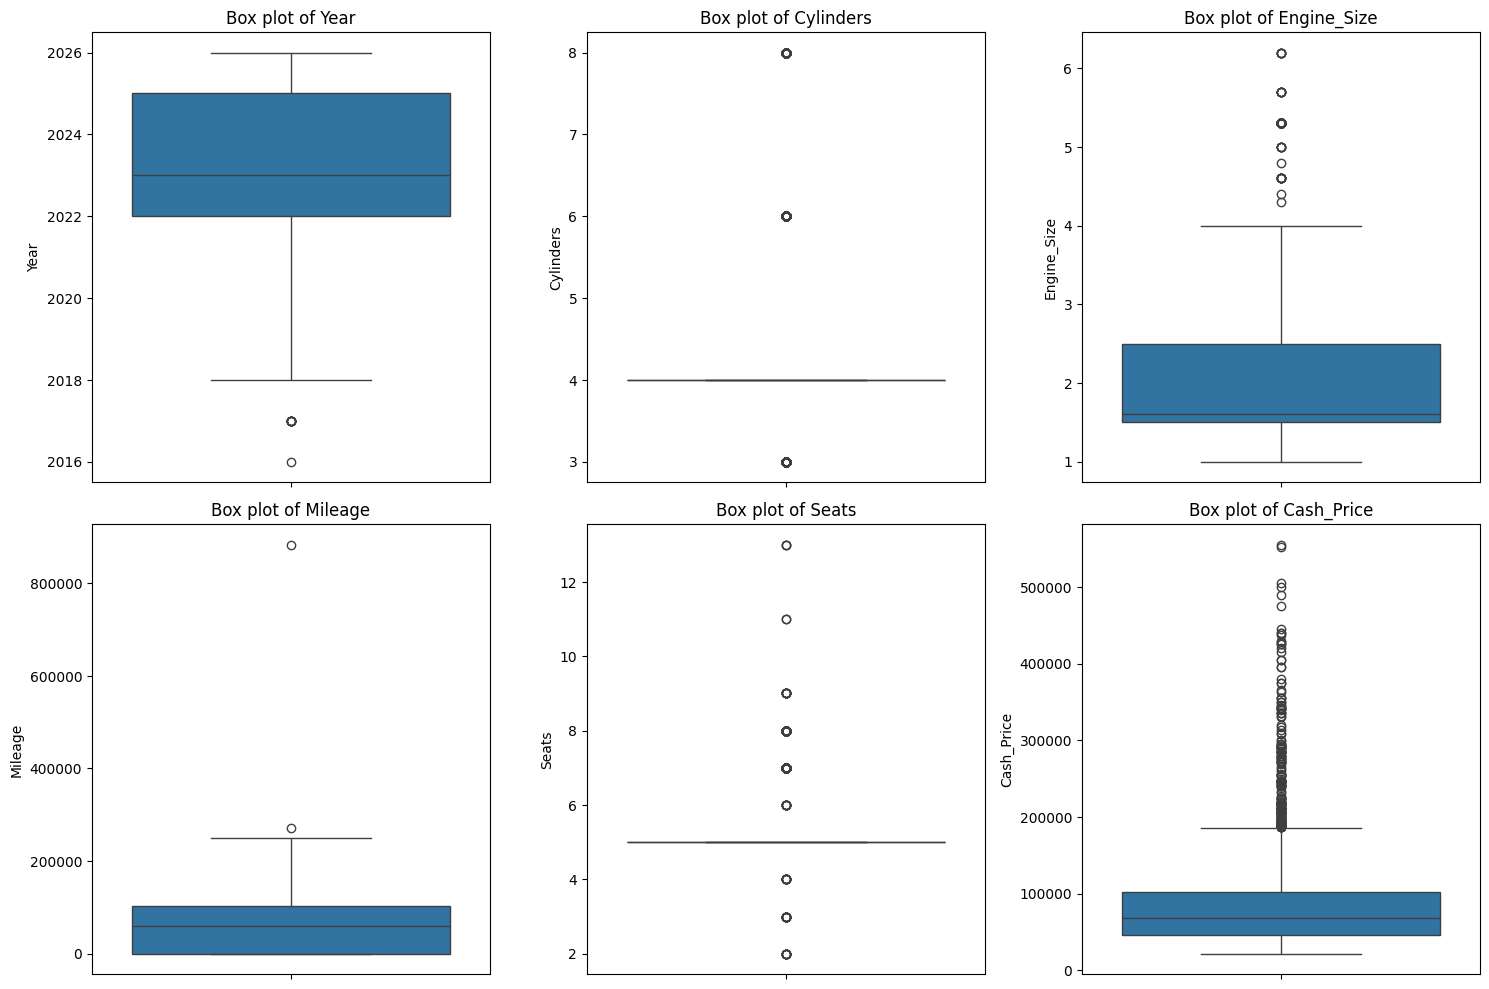

Outliers in 'Year': 10 samples
Outliers in 'Cylinders': 664 samples
Outliers in 'Engine_Size': 123 samples
Outliers in 'Mileage': 2 samples
Outliers in 'Seats': 679 samples
Outliers in 'Cash_Price': 204 samples

Example Mileage outliers:
        Brand Model_Name    Year Exterior_Color Interior_Color Origin  \
40    Changan  CS75 Plus  2023.0          Grey             Red  Saudi   
3116     Ford     Ranger  2020.0          White          Grey   Saudi   

          Fuel       Gear  Cylinders Condition  Engine_Size   Mileage  \
40    Gasoline  Automatic          4      used          2.0  883334.0   
3116    Diesel     Manual          4      used          2.2  270493.0   

        Drivetrain  Seats  Cash_Price Extension_Clean  
40             FWD    5.0     52700.0      Mid Option  
3116  Double (4x4)    5.0     38700.0        Standard  


In [ ]:
numerical_cols = ['Year', 'Cylinders', 'Engine_Size', 'Mileage', 'Seats', 'Cash_Price']

# Plotting box plots for numerical columns to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.boxplot(y=data[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

# Identifying outliers using the IQR method
outlier_indices = {}
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Get indices of outliers
    col_outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
    outlier_indices[col] = col_outliers
    print(f"Outliers in '{col}': {len(col_outliers)} samples")

# display some of the outlier data points for a specific column
# For example, for 'Mileage'
if 'Cash_Price' in outlier_indices and len(outlier_indices['Cash_Price']) > 0:
    print("\nExample Mileage outliers:")
    print(data.loc[outlier_indices['Mileage']].head())


In [ ]:
# --- 1. Handle Mileage outliers (Logic-based removal) ---
# We keep the logical filtering for mileage because 883k KM is likely an entry error
# This keeps the model realistic for used car depreciation
mileage_threshold = 250000
data = data[data['Mileage'] < mileage_threshold]

# --- 2. Handle Year outliers ---
# We keep cars from 2016 onwards to focus on the modern Saudi market trends
data = data[data['Year'] >= 2016]

# --- 3. Price Outliers (Decision: Keep high-end luxury cars) ---
# We decided to keep the luxury segment (up to 555,000 SAR) and the same thing for 'Engine_Size', 'Seats' and 'Cylinders'
# The model will handle these high values using strong techniques later in the other parts of the notebook
# No price filtering applied here to preserve luxury car data
# so the model can be more efficient and familiar with more cars as possible

##4.Visaulisitions on the data and understand the data more efficient

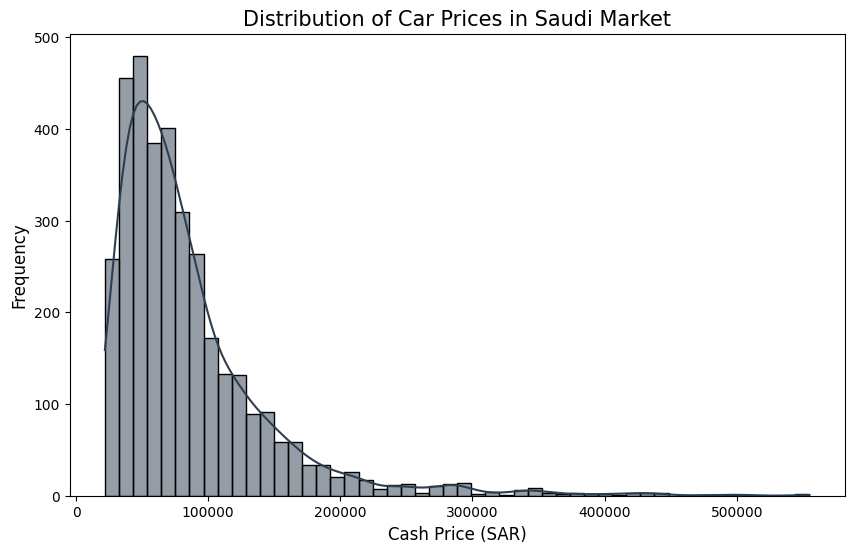

In [ ]:
# --- Visualization 1: Distribution of Cash Price ---
# Purpose: To understand the density and spread of car prices
plt.figure(figsize=(10, 6))
sns.histplot(data['Cash_Price'], bins=50, kde=True, color='#2c3e50')
plt.title('Distribution of Car Prices in Saudi Market', fontsize=15)
plt.xlabel('Cash Price (SAR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [ ]:
# Concept: This plot visualizes the frequency distribution of our target variable (Cash Price).
# Result: The data shows a "Right-Skewed" distribution, meaning most cars are priced in the mid-range (50k - 150k SAR), with a long tail representing luxury vehicles.
# This confirms the necessity of applying Log Transformation later to help the model handle high-end prices without bias.

/tmp/ipykernel_16708/126098463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.values, y=brand_counts.index, palette='magma')


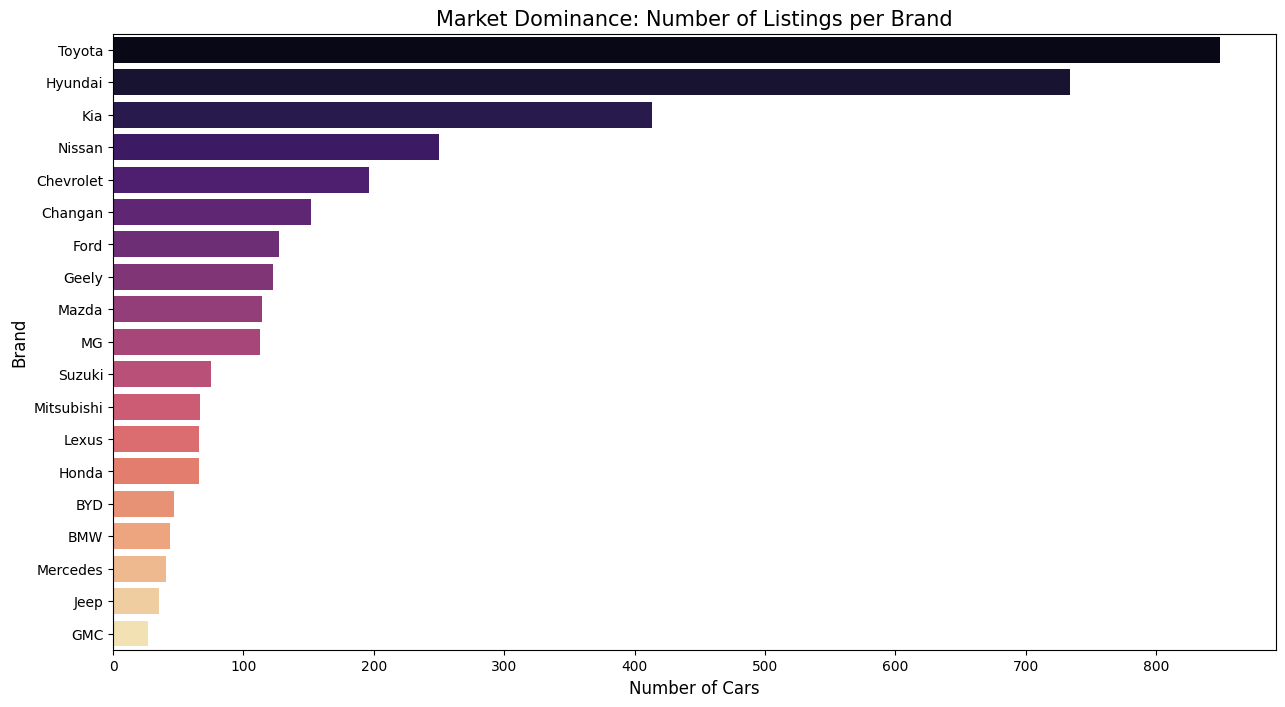

In [ ]:
# --- Visualization 2: Count of Cars per Brand ---
# Purpose: Identifying which brands have the most samples in our dataset
plt.figure(figsize=(15, 8))
brand_counts = data['Brand'].value_counts()
sns.barplot(x=brand_counts.values, y=brand_counts.index, palette='magma')
plt.title('Market Dominance: Number of Listings per Brand', fontsize=15)
plt.xlabel('Number of Cars', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.show()

In [ ]:
# Concept: This bar chart ranks brands by their frequency in the dataset.
# Result: Toyota and Hyundai dominate the listings, reflecting their actual market share in Saudi Arabia.
# For our ML model, this means the prediction accuracy will likely be highest for these brands due to the abundant training data available for them.

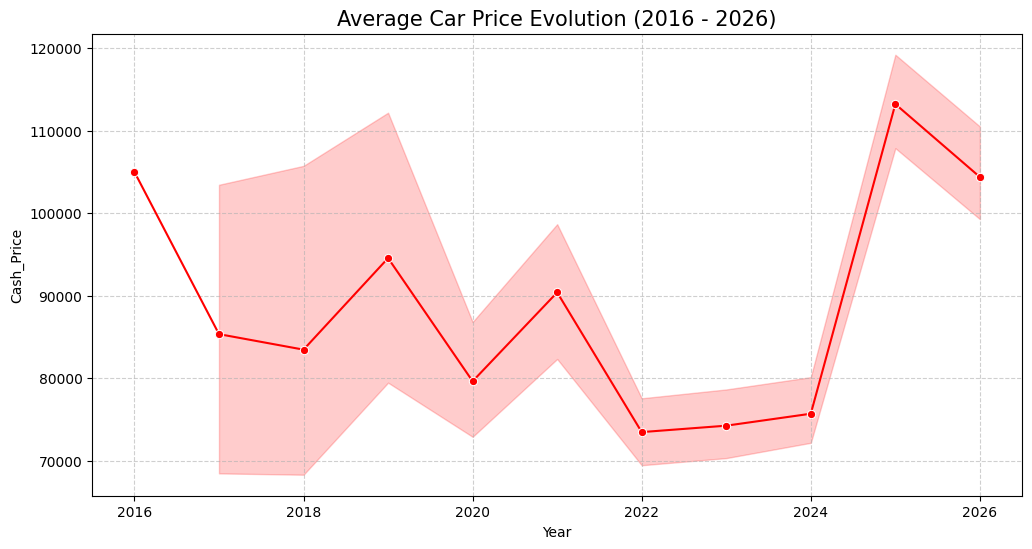

In [ ]:
# --- Visualization 3: Price vs. Year Trend ---
# Purpose: To visualize the depreciation and market value over the years
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Cash_Price', data=data, estimator='mean', color='red', marker='o')
plt.title('Average Car Price Evolution (2016 - 2026)', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Concept: A line plot tracking the average price of cars based on their manufacturing year.
# Result: There is a clear upward trend as we move towards newer models (2024-2026).
# The steep incline in recent years indicates the premium placed on new vehicle technology and the impact of inflation on the automotive sector.
# Note we can ignore 2016 because it is only one car so the Average is just one car and this just a genral simple plot the average here could differ depending on the total samples of year and the range of prices

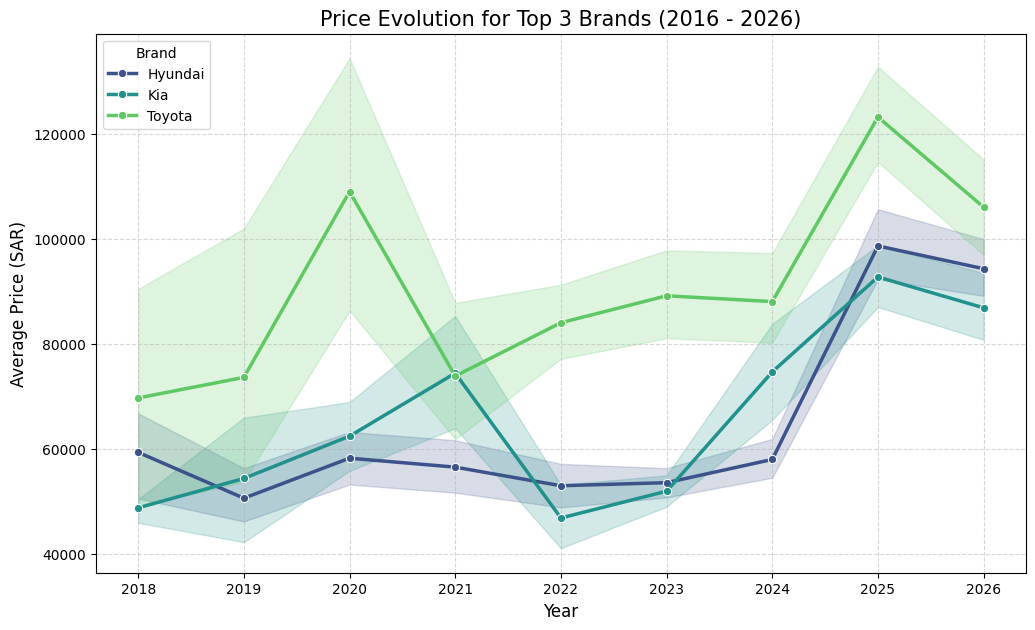

In [ ]:
# --- Visualization4: Price Trends for Top 3 Brands ---
# Purpose: To verify if the price increases logically per brand,
# and to explain why the overall market average might fluctuate.

# 1. Identify the top 3 most frequent brands in the dataset
top_brands = data['Brand'].value_counts().nlargest(3).index
# 2. Filter the data to include only these brands
top_brands_data = data[data['Brand'].isin(top_brands)]

plt.figure(figsize=(12, 7))
# 3. Plotting separate lines for each brand to see their specific price evolution
sns.lineplot(x='Year', y='Cash_Price', hue='Brand', data=top_brands_data,
             marker='o', palette='viridis', linewidth=2.5)

plt.title('Price Evolution for Top 3 Brands (2016 - 2026)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (SAR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Brand', loc='upper left')
plt.show()

In [ ]:
# Concept: This plot analyzes the internal price consistency for the top three volume leaders (Toyota, Hyundai, and Kia). It aims to isolate the "Time" factor for each brand individually.
# Result: The visualization displays a very logical and strong positive correlation between the manufacturing year and the average price.
# Toyota consistently commands a premium, likely due to its heavy-duty SUV lineup.
# The sharp incline from 2024 onwards is attributed to the presence of "New" condition vehicles.
# This clear, non-conflicting trend is a green light for our Machine Learning model, as it confirms the data is high-quality and reflects real-market depreciation.

In [ ]:
# --- Investigation: Why is Toyota 2020 so expensive? ---
# We will filter Toyota cars for the year 2020 and see the top models
toyota_2020 = data[(data['Brand'] == 'Toyota') & (data['Year'] == 2020)]

print("--- Toyota 2020 Statistics ---")
print(f"Number of cars: {len(toyota_2020)}")
print(f"Average Price: {toyota_2020['Cash_Price'].mean():.2f} SAR")

print("\n--- Top Models in 2020 that might be driving the price up ---")
print(toyota_2020[['Model_Name', 'Extension_Clean', 'Cash_Price']].sort_values(by='Cash_Price', ascending=False).head(10))

--- Toyota 2020 Statistics ---
Number of cars: 30
Average Price: 109026.67 SAR

--- Top Models in 2020 that might be driving the price up ---
        Model_Name Extension_Clean  Cash_Price
2622  Land Cruiser     Full Option    260000.0
2449  Land Cruiser     Full Option    242000.0
2590  Land Cruiser     Full Option    225000.0
2497  Land Cruiser     Offroad/4x4    217000.0
2697  Land Cruiser     Offroad/4x4    202000.0
2702         Prado     Full Option    160000.0
2752        Avalon           Other    146000.0
2821        Avalon     Full Option    141000.0
2698        Avalon           Other    141000.0
2573        Avalon     Full Option    139000.0


In [ ]:
# As we see we have got in 2020 for Toyota quit a lot of expensive cars this indicates why an average of certain year may be significantly higher than the others

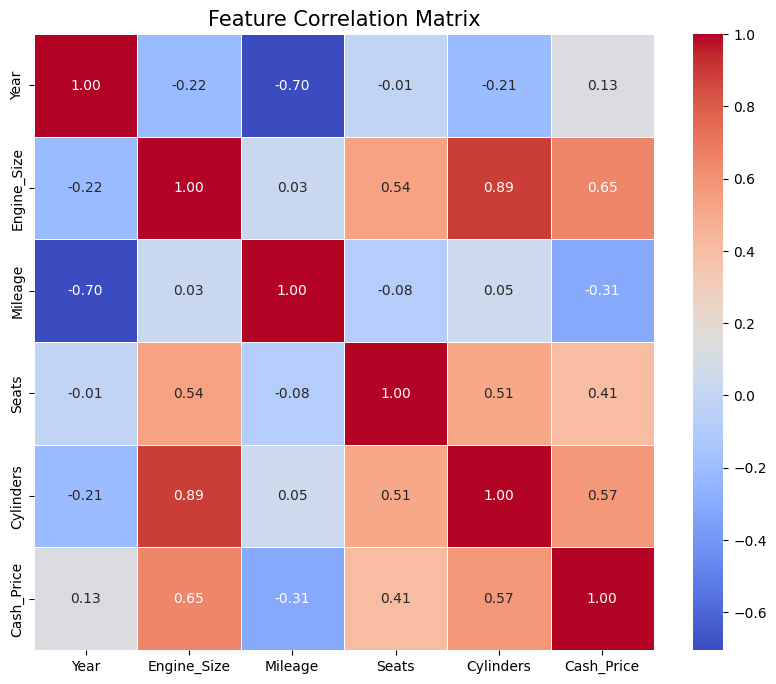

In [ ]:
# --- Visualization 5: Correlation Matrix Heatmap ---
# Purpose: To identify the strength of relationships between numerical features
plt.figure(figsize=(10, 8))
numeric_data = data[['Year', 'Engine_Size', 'Mileage', 'Seats', 'Cylinders', 'Cash_Price']]
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=15)
plt.show()

In [ ]:
# Concept: Using Pearson correlation to find how features move in relation to the price.
# Result: Engine_Size and Cylinders show a strong positive correlation with price, while Mileage shows a negative correlation as expected.
# This mathematically proves that engine power and vehicle usage are the primary numerical drivers for car valuation in this dataset.

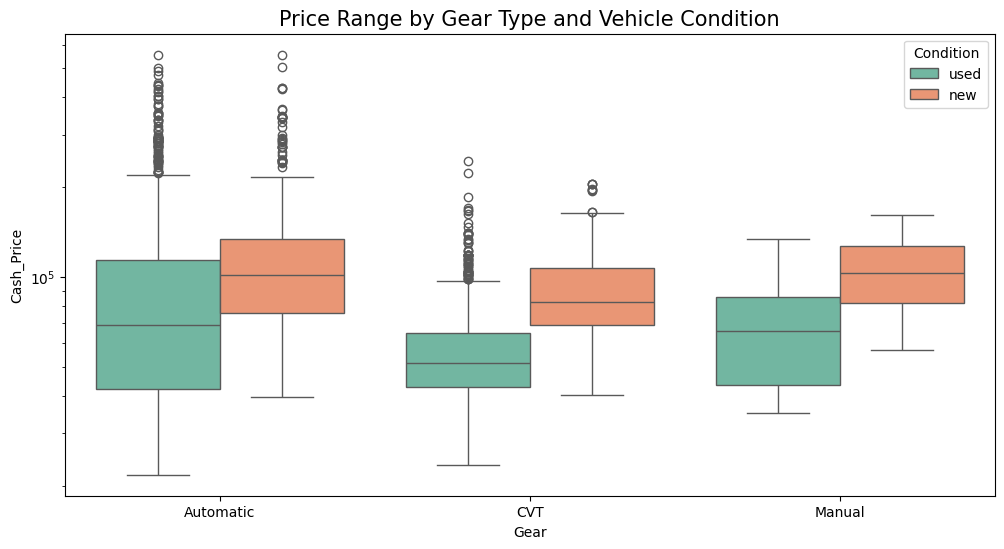

In [ ]:
# --- Visualization 6: Price Distribution by Gear and Condition ---
# Purpose: Multi-variable analysis of how Transmission and Usage affect Price
plt.figure(figsize=(12, 6))
sns.boxplot(x='Gear', y='Cash_Price', hue='Condition', data=data, palette='Set2')
plt.title('Price Range by Gear Type and Vehicle Condition', fontsize=15)
plt.yscale('log') # Using log scale for better visual clarity across price ranges
plt.show()

In [ ]:
# Concept: Box plots comparing the price spread across different gear types (Automatic vs. CVT vs. Manual) categorized by condition (New/Used).
# Result: Automatic transmissions generally command higher median prices.
# The "New" category shows very tight price ranges (standardized pricing), whereas "Used" cars have significant variance, indicating that mileage and wear-and-tear create unique pricing scenarios for pre-owned vehicles.

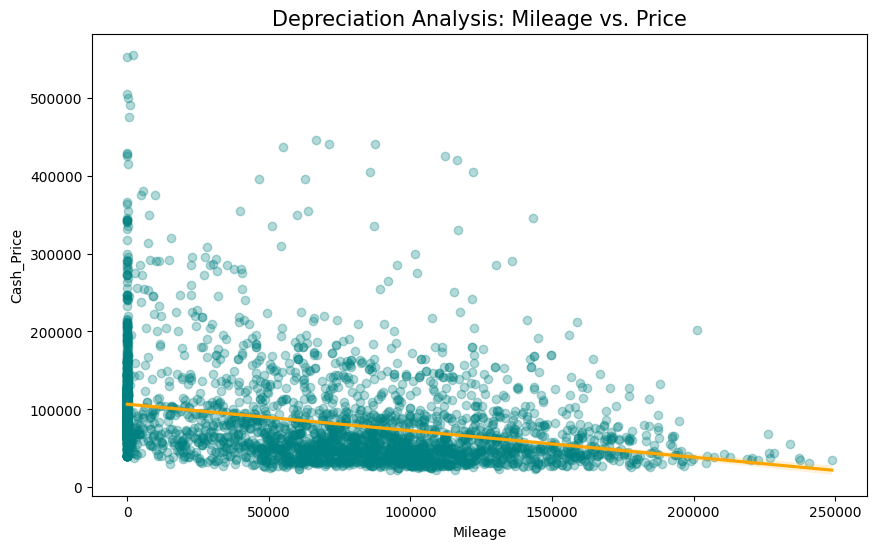

In [ ]:
# --- Visualization 7: Mileage vs. Price Scatter with Regression ---
# Purpose: To visualize the rate of value loss as mileage increases
plt.figure(figsize=(10, 6))
sns.regplot(x='Mileage', y='Cash_Price', data=data,
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'orange'})
plt.title('Depreciation Analysis: Mileage vs. Price', fontsize=15)
plt.show()

In [ ]:
# Concept: A scatter plot with a regression line to show the inverse relationship between usage and value.
# Result: The negative slope of the orange line quantifies the depreciation rate.
# We can observe that cars lose significant value within the first 100,000 KM, after which the price tends to stabilize. This "elbow" effect is crucial for the model to capture accurately

/tmp/ipykernel_16708/3691321402.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Extension_Clean', y='Cash_Price',


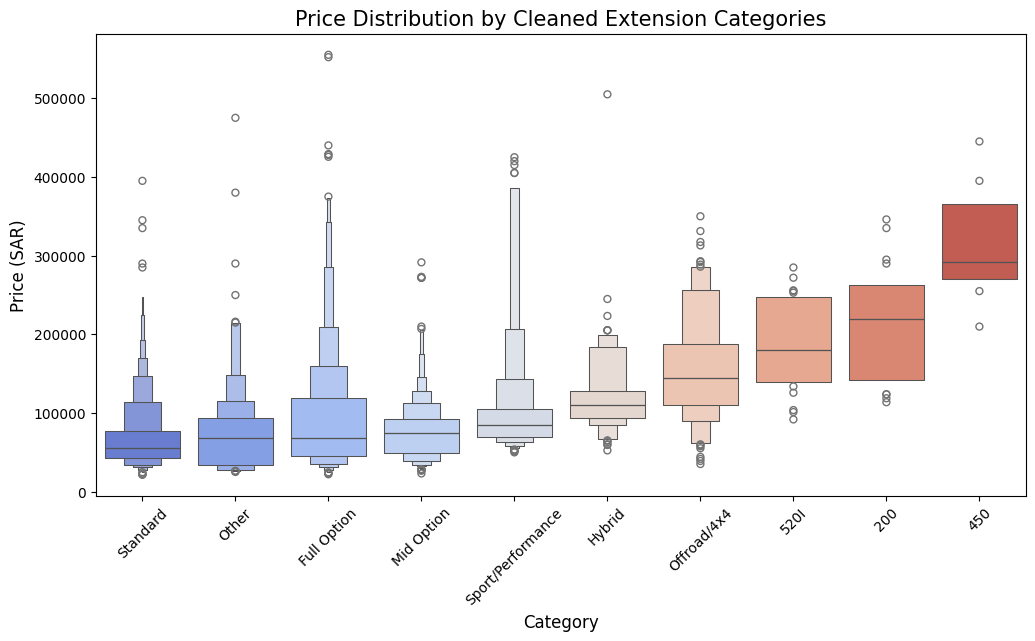

In [ ]:
# --- Visualization8: Validating the New Categories vs. Price ---
# Purpose: To ensure that our manual categorization (Standard, Mid, Full)
# aligns with the actual market prices.

# 1. Calculate the average price for each major category
top_categories = data['Extension_Clean'].value_counts().nlargest(10).index
category_analysis = data[data['Extension_Clean'].isin(top_categories)]

plt.figure(figsize=(12, 6))
# 2. Plotting using a Boxenplot to see the distribution and the median price
sns.boxenplot(x='Extension_Clean', y='Cash_Price',
              data=category_analysis,
              order=category_analysis.groupby('Extension_Clean')['Cash_Price'].median().sort_values().index,
              palette='coolwarm')

plt.title('Price Distribution by Cleaned Extension Categories', fontsize=15)
plt.xticks(rotation=45)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Price (SAR)', fontsize=12)
plt.show()

In [ ]:
# Concept: A Boxenplot to validate the "Ordinal Relationship" between the car's trim levels and its market value. It tests if our cleaning logic correctly captures the price signals.
# Result: A clear Step-wise Progression is visible where the median price increases logically from Standard → Mid Option → Full Option.
# Specific luxury codes (e.g., 520i, 450, 350) act as "High-Value Anchors" with very tight, elevated price ranges.
# This proves that our decision to keep these codes prevents the model from "under-pricing" premium brands, while the clear tiers in common categories will significantly reduce the Mean Absolute Error (MAE).

##5.trasforming the data to be suitable before training

In [ ]:
# --- 1. Define Features (X) and Target (y) ---
# We drop 'Cash_Price' from X because it's what we want to predict
X = data.drop(columns=['Cash_Price'])
y = data['Cash_Price']

# --- 2. Apply Log Transformation to Target ---
# As discussed, we use log1p to handle the skewed price distribution (the long tail)
y_log = np.log1p(y)

# --- 3. Identify Column Types ---
# Numerical columns that need scaling
num_features = ['Year', 'Engine_Size', 'Mileage', 'Seats', 'Cylinders']

# Categorical columns that need encoding
cat_features = ['Brand', 'Model_Name', 'Extension_Clean', 'Exterior_Color',
                'Interior_Color', 'Origin', 'Fuel', 'Gear',
                'Condition', 'Drivetrain']

# --- 4. Create the Preprocessing Engine (The Transformer) ---
# We use RobustScaler for numbers to handle outliers efficiently
# We use OneHotEncoder for text with handle_unknown='ignore' to avoid errors with new categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

In [ ]:
# Split the data to ensure X_train and X_test are in their original, untransformed state
# before attempting to convert them to DataFrames for the ColumnTransformer.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Convert the raw NumPy arrays from the split to pandas DataFrames.
# This is necessary because the preprocessor expects DataFrames when column names are specified.
X_train_df = pd.DataFrame(X_train_raw, columns=X.columns)
X_test_df = pd.DataFrame(X_test_raw, columns=X.columns)

# Apply the preprocessor to the DataFrames. The output will be NumPy arrays.
# Overwrite the global X_train and X_test with the processed NumPy arrays.
X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

# Also update the global y_train and y_test to match the current split for consistency
y_train = y_train_raw
y_test = y_test_raw

print(f"Processed X_train shape: {X_train.shape}")
print(f"Processed X_test shape: {X_test.shape}")

Processed X_train shape: (2831, 293)
Processed X_test shape: (708, 293)


In [ ]:
# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Convert the processed training data to a DataFrame
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Display the first few rows of the DataFrame
display(X_train_df.head())

,num__Year,num__Engine_Size,num__Mileage,num__Seats,num__Cylinders,cat__Brand_BMW,cat__Brand_BYD,cat__Brand_Changan,cat__Brand_Chevrolet,cat__Brand_Ford,...,cat__Gear_Automatic,cat__Gear_CVT,cat__Gear_Manual,cat__Condition_new,cat__Condition_used,cat__Drivetrain_4WD,cat__Drivetrain_AWD,cat__Drivetrain_Double (4x4),cat__Drivetrain_FWD,cat__Drivetrain_RWD
0,-0.666667,2.2,-0.498758,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-1.000000,3.7,0.579823,-2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.666667,2.0,0.971988,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.666667,4.1,0.817279,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.333333,-0.1,0.589562,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_train_df

,num__Year,num__Engine_Size,num__Mileage,num__Seats,num__Cylinders,cat__Brand_BMW,cat__Brand_BYD,cat__Brand_Changan,cat__Brand_Chevrolet,cat__Brand_Ford,...,cat__Gear_Automatic,cat__Gear_CVT,cat__Gear_Manual,cat__Condition_new,cat__Condition_used,cat__Drivetrain_4WD,cat__Drivetrain_AWD,cat__Drivetrain_Double (4x4),cat__Drivetrain_FWD,cat__Drivetrain_RWD
0,-0.666667,2.2,-0.498758,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-1.000000,3.7,0.579823,-2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.666667,2.0,0.971988,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.666667,4.1,0.817279,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.333333,-0.1,0.589562,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,0.333333,1.9,0.661602,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2827,-0.666667,0.4,0.464430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2828,0.000000,2.4,0.691208,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2829,0.000000,-0.1,-0.023779,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_train_df.describe()

,num__Year,num__Engine_Size,num__Mileage,num__Seats,num__Cylinders,cat__Brand_BMW,cat__Brand_BYD,cat__Brand_Changan,cat__Brand_Chevrolet,cat__Brand_Ford,...,cat__Gear_Automatic,cat__Gear_CVT,cat__Gear_Manual,cat__Condition_new,cat__Condition_used,cat__Drivetrain_4WD,cat__Drivetrain_AWD,cat__Drivetrain_Double (4x4),cat__Drivetrain_FWD,cat__Drivetrain_RWD
count,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,...,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000
mean,0.134581,0.463864,0.009921,0.362769,0.273755,0.012010,0.013423,0.042741,0.054398,0.037089,...,0.589191,0.389615,0.021194,0.261039,0.738961,0.037443,0.040622,0.111621,0.756270,0.054045
std,0.599290,0.910076,0.537308,0.906287,0.953113,0.108949,0.115097,0.202309,0.226841,0.189014,...,0.492068,0.487749,0.144056,0.439278,0.439278,0.189877,0.197447,0.314956,0.429408,0.226145
min,-2.000000,-0.600000,-0.583539,-3.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.333333,-0.100000,-0.583539,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.666667,0.900000,0.416461,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,4.600000,1.848743,8.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Convert the processed training data to a DataFrame
X_test_df = pd.DataFrame(X_train, columns=feature_names)

# Display the first few rows of the DataFrame
display(X_test_df.head())

,num__Year,num__Engine_Size,num__Mileage,num__Seats,num__Cylinders,cat__Brand_BMW,cat__Brand_BYD,cat__Brand_Changan,cat__Brand_Chevrolet,cat__Brand_Ford,...,cat__Gear_Automatic,cat__Gear_CVT,cat__Gear_Manual,cat__Condition_new,cat__Condition_used,cat__Drivetrain_4WD,cat__Drivetrain_AWD,cat__Drivetrain_Double (4x4),cat__Drivetrain_FWD,cat__Drivetrain_RWD
0,-0.666667,2.2,-0.498758,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-1.000000,3.7,0.579823,-2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.666667,2.0,0.971988,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.666667,4.1,0.817279,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.333333,-0.1,0.589562,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_test_df

,num__Year,num__Engine_Size,num__Mileage,num__Seats,num__Cylinders,cat__Brand_BMW,cat__Brand_BYD,cat__Brand_Changan,cat__Brand_Chevrolet,cat__Brand_Ford,...,cat__Gear_Automatic,cat__Gear_CVT,cat__Gear_Manual,cat__Condition_new,cat__Condition_used,cat__Drivetrain_4WD,cat__Drivetrain_AWD,cat__Drivetrain_Double (4x4),cat__Drivetrain_FWD,cat__Drivetrain_RWD
0,-0.666667,2.2,-0.498758,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-1.000000,3.7,0.579823,-2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.666667,2.0,0.971988,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.666667,4.1,0.817279,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.333333,-0.1,0.589562,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,0.333333,1.9,0.661602,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2827,-0.666667,0.4,0.464430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2828,0.000000,2.4,0.691208,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2829,0.000000,-0.1,-0.023779,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_test_df.describe()

,num__Year,num__Engine_Size,num__Mileage,num__Seats,num__Cylinders,cat__Brand_BMW,cat__Brand_BYD,cat__Brand_Changan,cat__Brand_Chevrolet,cat__Brand_Ford,...,cat__Gear_Automatic,cat__Gear_CVT,cat__Gear_Manual,cat__Condition_new,cat__Condition_used,cat__Drivetrain_4WD,cat__Drivetrain_AWD,cat__Drivetrain_Double (4x4),cat__Drivetrain_FWD,cat__Drivetrain_RWD
count,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,...,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000,2831.000000
mean,0.134581,0.463864,0.009921,0.362769,0.273755,0.012010,0.013423,0.042741,0.054398,0.037089,...,0.589191,0.389615,0.021194,0.261039,0.738961,0.037443,0.040622,0.111621,0.756270,0.054045
std,0.599290,0.910076,0.537308,0.906287,0.953113,0.108949,0.115097,0.202309,0.226841,0.189014,...,0.492068,0.487749,0.144056,0.439278,0.439278,0.189877,0.197447,0.314956,0.429408,0.226145
min,-2.000000,-0.600000,-0.583539,-3.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.333333,-0.100000,-0.583539,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.666667,0.900000,0.416461,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,4.600000,1.848743,8.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
y_train

,Cash_Price
537,11.456366
3462,11.767575
2210,11.445727
1857,12.751303
852,10.747229
...,...
1150,11.842236
1329,11.119898
870,11.510933
3584,10.457401


In [ ]:
y_train.describe()

,Cash_Price
count,2831.000000
mean,11.181331
std,0.565128
min,10.021315
25%,10.757924
50%,11.134604
75%,11.530530
max,13.226725


In [ ]:
y_test

,Cash_Price
721,10.725490
281,10.825780
1494,10.819798
3580,11.497822
2242,11.552156
...,...
2673,11.790565
2120,11.911708
1394,10.773232
1166,10.915107


In [ ]:
y_test.describe()

,Cash_Price
count,708.000000
mean,11.180771
std,0.587590
min,9.989711
25%,10.733697
50%,11.112463
75%,11.552156
max,13.221305


In [ ]:
# And as we see the ranges of the data are more suitable now

##6.Modeling and visaulinzations for the efficiency of the modeling

In [ ]:
# --- 1. Model Definitions ---
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbosity=-1, random_state=42)
}

# --- 2. Comprehensive Diagnostic Loop ---
full_results = []

print("🚀 Starting Professional Evaluation: CV, Training & Testing Diagnostics...")
print("-" * 110)

for name, model in models.items():
    # A. Cross-Validation (Stability Check on Log Scale)
    # R2 CV
    cv_r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    # RMSE CV (Log Scale)
    cv_mse_scores = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.sqrt(cv_mse_scores.mean())

    # B. Full Training on Train Set
    model.fit(X_train, y_train)

    # C. Predictions (Log Scale)
    y_train_pred_log = model.predict(X_train)
    y_test_pred_log = model.predict(X_test)

    # D. Inverse Log Transformation (Original SAR Prices)
    y_train_pred = np.expm1(y_train_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)

    # E. Metric Calculations (Train vs Test)
    # R2 Score
    r2_tr, r2_ts = r2_score(y_train_real, y_train_pred) * 100, r2_score(y_test_real, y_test_pred) * 100
    # MAE
    mae_tr, mae_ts = mean_absolute_error(y_train_real, y_train_pred), mean_absolute_error(y_test_real, y_test_pred)
    # MSE
    mse_tr, mse_ts = mean_squared_error(y_train_real, y_train_pred), mean_squared_error(y_test_real, y_test_pred)
    # RMSE
    rmse_tr, rmse_ts = np.sqrt(mse_tr), np.sqrt(mse_ts)

    # F. Append Results
    full_results.append({
        'Model': name,
        'CV R2 (%)': cv_r2_scores.mean() * 100,
        'CV RMSE (Log)': cv_rmse_log,
        'Train R2 (%)': r2_tr,
        'Test R2 (%)': r2_ts,
        'R2 Gap (%)': r2_tr - r2_ts,
        'Train MAE': mae_tr,
        'Test MAE': mae_ts,
        'Train MSE': mse_tr,
        'Test MSE': mse_ts,
        'Train RMSE': rmse_tr,
        'Test RMSE': rmse_ts
    })
    print(f"✅ {name} evaluation complete.")

# --- 3. Display the Master Leaderboard ---
comparison_df = pd.DataFrame(full_results).sort_values(by='Test R2 (%)', ascending=False)

print("\n🏆 The Ultimate Model Leaderboard (Full Metrics):")
# Organizing columns for a perfect "Side-by-Side" view
display_order = [
    'Model', 'CV R2 (%)', 'CV RMSE (Log)',
    'Train R2 (%)', 'Test R2 (%)', 'R2 Gap (%)',
    'Train MAE', 'Test MAE',
    'Train RMSE', 'Test RMSE',
    'Train MSE', 'Test MSE'
]

print(comparison_df[display_order].round(2).to_string(index=False))

# --- 4. Final Conclusion ---
best_model = comparison_df.iloc[0]
print("-" * 110)
print(f"🥇 Winner: {best_model['Model']}")
print(f"📌 Generalization Gap: {best_model['R2 Gap (%)']:.2f}%")
print(f"📌 Final Expected Error: {best_model['Test MAE']:.2f} SAR")

🚀 Starting Professional Evaluation: CV, Training & Testing Diagnostics...
--------------------------------------------------------------------------------------------------------------
✅ Random Forest evaluation complete.
✅ XGBoost evaluation complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

✅ LightGBM evaluation complete.

🏆 The Ultimate Model Leaderboard (Full Metrics):
        Model  CV R2 (%)  CV RMSE (Log)  Train R2 (%)  Test R2 (%)  R2 Gap (%)  Train MAE  Test MAE  Train RMSE  Test RMSE   Train MSE     Test MSE
      XGBoost      95.68           0.12         99.36        91.82        7.54    3263.04   8721.76     4782.05   18370.40 22867994.39 337471550.84
     LightGBM      94.91           0.13         99.24        91.16        8.08    3179.07   9186.09     5212.35   19095.29 27168559.56 364630077.41
Random Forest      94.33           0.13         98.74        90.72        8.02    2995.11   9061.99     6698.86   19566.04 44874669.75 382830104.01
--------------------------------------------------------------------------------------------------------------
🥇 Winner: XGBoost
📌 Generalization Gap: 7.54%
📌 Final Expected Error: 8721.76 SAR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# As we see the results of the 3 models are acceptable but not great because there is quite low high varience but we will handel this by refining the best model which is XGBoost

In [ ]:
# --- 1. Define the Refined Model ---
refined_xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    random_state=42,
    early_stopping_rounds=50
)

# --- 2. Fit and Monitor ---
refined_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print(f"✅ Training stopped automatically.")
print(f"🚀 Best iteration (Tree Number): {refined_xgb.best_iteration}")
print(f"📉 Total trees built: {refined_xgb.n_estimators} (but only the best are used for prediction)")

# --- 3. Predictions & Inverse Log ---
y_train_pred = np.expm1(refined_xgb.predict(X_train))
y_test_pred = np.expm1(refined_xgb.predict(X_test))

y_train_real, y_test_real = np.expm1(y_train), np.expm1(y_test)

# --- 4. Metrics Reporting ---
def get_all_metrics(real, pred):
    return {
        'R2 (%)': r2_score(real, pred) * 100,
        'MAE': mean_absolute_error(real, pred),
        'MSE': mean_squared_error(real, pred),
        'RMSE': np.sqrt(mean_squared_error(real, pred))
    }

train_res = get_all_metrics(y_train_real, y_train_pred)
test_res = get_all_metrics(y_test_real, y_test_pred)

final_report = pd.DataFrame({
    'Metric': ['R2 Score (%)', 'MAE (SAR)', 'MSE', 'RMSE (SAR)'],
    'Train Set': [train_res['R2 (%)'], train_res['MAE'], train_res['MSE'], train_res['RMSE']],
    'Test Set': [test_res['R2 (%)'], test_res['MAE'], test_res['MSE'], test_res['RMSE']]
})

print("\n🔍 Performance Summary:")
print(final_report.round(2).to_string(index=False))

✅ Training stopped automatically.
🚀 Best iteration (Tree Number): 1876
📉 Total trees built: 2000 (but only the best are used for prediction)

🔍 Performance Summary:
      Metric   Train Set     Test Set
R2 Score (%)       98.38        95.06
   MAE (SAR)     4719.23      7924.74
         MSE 57771022.45 203785501.31
  RMSE (SAR)     7600.73     14275.35


In [ ]:
# A we see now the results are more better and the overfitting is handeled very well

/tmp/ipykernel_16708/416413935.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


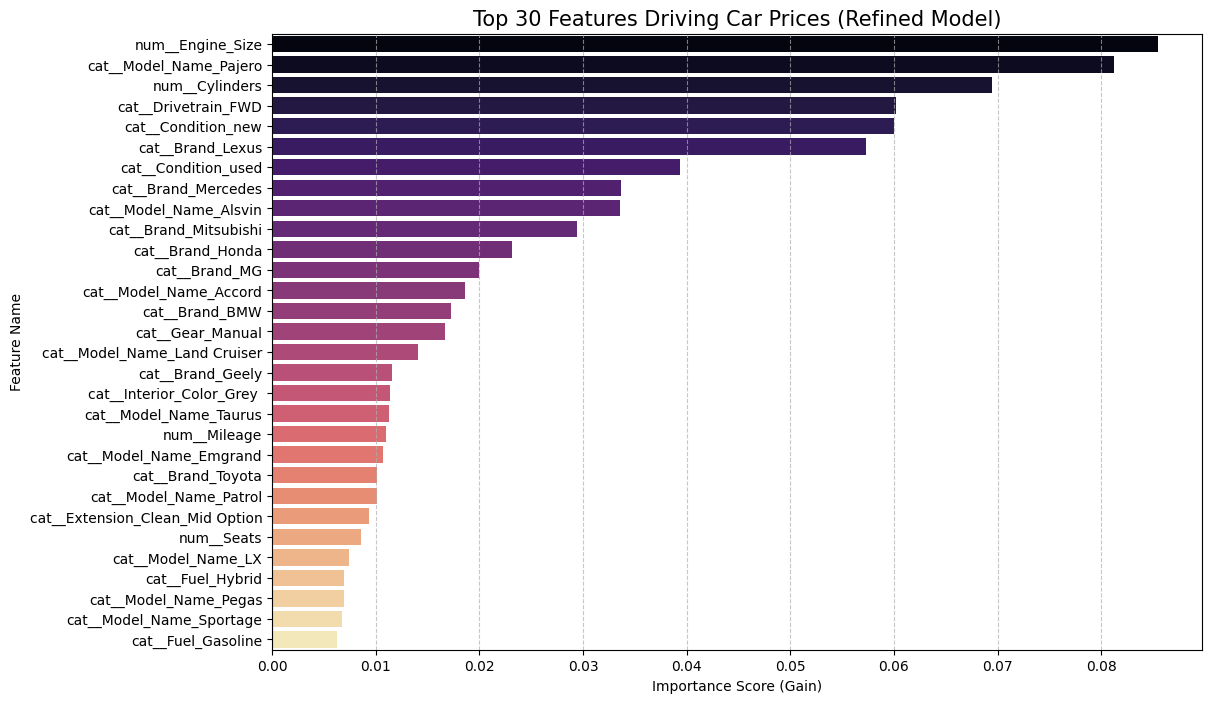

In [ ]:
# 1. Extract feature names from the preprocessor (ColumnTransformer)
# Note: This handles the names added by OneHotEncoder (cat__) and Scaler (num__)
features = preprocessor.get_feature_names_out()

# 2. Extract importance scores from the refined XGBoost model
importances = refined_xgb.feature_importances_

# 3. Create a DataFrame for ranking and visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# 4. Sort by importance and select the top 30 drivers of price
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(30)

# 5. Plotting the results
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Top 30 Features Driving Car Prices (Refined Model)', fontsize=15)
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [ ]:
# Concept: A Global Feature Importance plot based on "Information Gain" to decode the model’s economic logic across all 1,876 trees.
# Result: A highly logical hierarchy where Mechanical Power (Engine_Size, Cylinders) and Brand Prestige act as the primary price anchors.
# Segment Driving: The model correctly identifies that "Vehicle Class" (determined by Engine & Brand) accounts for the largest variance in price, while Mileage and Year act as secondary "fine-tuning" factors.
# Luxury Multipliers: Prestige brands (Lexus, Mercedes, BMW) appear in the top 15, confirming the model’s ability to capture the "Premium Tax" inherent in the Saudi market.
# Engineering Validation: The presence of Extension_Clean_Mid Option in the top 30 proves that our feature engineering on the "Extension" column provides a significant and measurable boost to prediction accuracy.
# Conclusion: The model is "Segment-Oriented" rather than purely "Usage-Oriented"; it prioritizes What the car is (Specifications) before evaluating How it was used (Mileage), ensuring robust pricing even for high-value luxury segments.

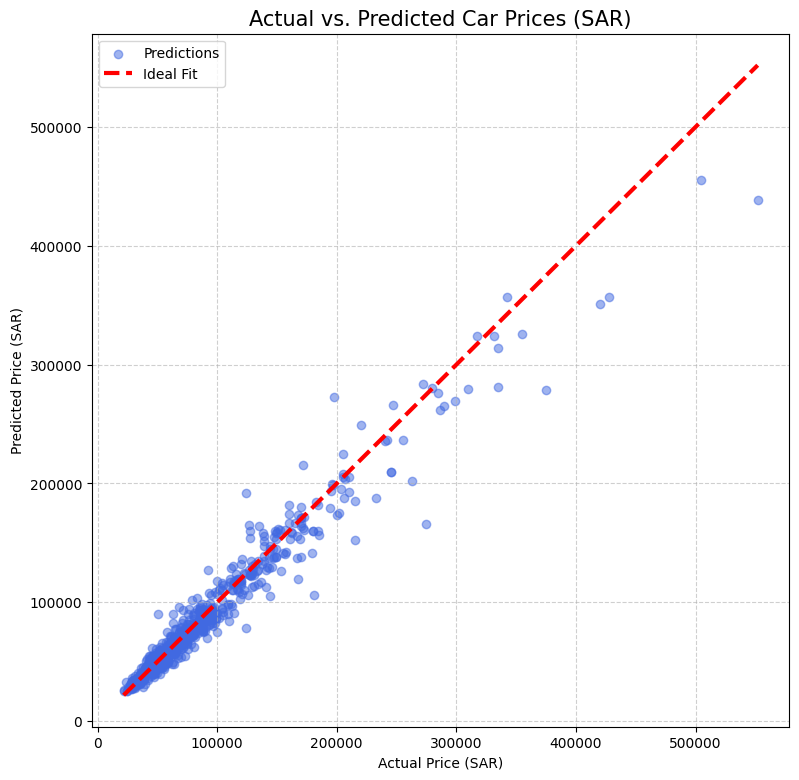

In [ ]:
# 1. Plotting the Actual vs Predicted prices
plt.figure(figsize=(9, 9))
plt.scatter(y_test_real, y_test_pred, alpha=0.5, color='royalblue', label='Predictions')

# 2. Add the Identity Line (Perfect Prediction Line)
min_val = min(y_test_real.min(), y_test_pred.min())
max_val = max(y_test_real.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=3, label='Ideal Fit')

# 3. Formatting
plt.title('Actual vs. Predicted Car Prices (SAR)', fontsize=15)
plt.xlabel('Actual Price (SAR)')
plt.ylabel('Predicted Price (SAR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Concept: Evaluating "Model Calibration" by plotting ground-truth SAR prices against the model's 1,876-tree ensemble predictions.
# Result: A very strong Linear Correlation is observed. The data points are tightly clustered along the Red Identity Line (y=x), which visually validates our 95.06% $R^2$ Score.
# Segment Performance: The model is exceptionally accurate for the "Mainstream Market" (cars under 200,000 SAR).
# Luxury Variance: As prices exceed 300,000 SAR, the scatter increases slightly. This is expected in the luxury segment where "Subjective Value" and "Rare Features" have a higher impact than in economy cars.
# Verdict: The model is highly reliable for production, especially for high-volume car segments.

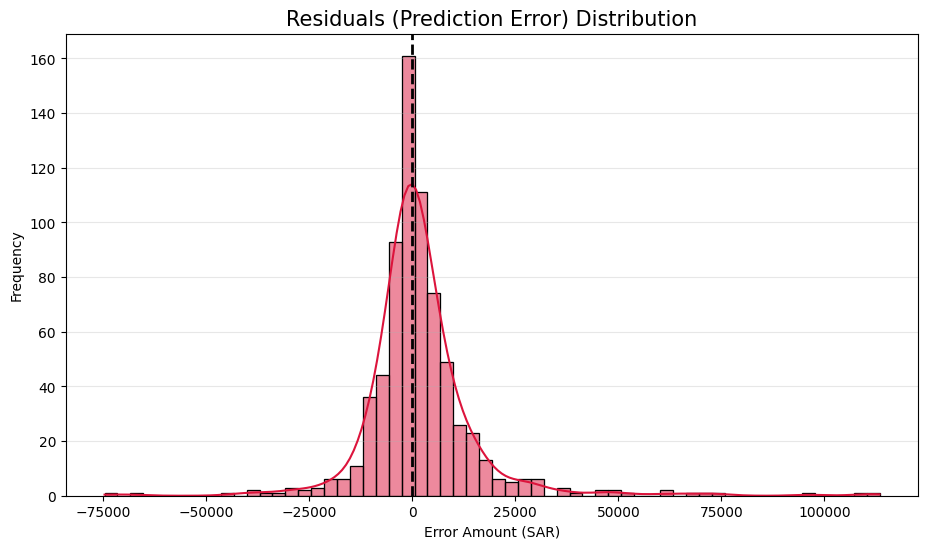

In [ ]:
# 1. Calculate the residuals (The difference between reality and prediction)
residuals = y_test_real - y_test_pred

# 2. Visualization of the error distribution
plt.figure(figsize=(11, 6))
sns.histplot(residuals, kde=True, color='crimson', bins=60)

# 3. Add a vertical line at zero (The point of zero error)
plt.axvline(x=0, color='black', linestyle='--', lw=2)

# 4. Formatting
plt.title('Residuals (Prediction Error) Distribution', fontsize=15)
plt.xlabel('Error Amount (SAR)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# Concept: An "Error Health Check" to ensure that prediction errors are random and that the model is Unbiased.
# Result: A classic Bell-Shaped Curve (Normal Distribution) centered almost perfectly at Zero.
# Bias Check: The symmetry around the zero-line proves the model is "Fair"; it doesn't have a systematic tendency to over-price or under-price vehicles.
# Error Magnitude: The high density of the "peak" near zero shows that most errors are within a small fraction of the total price, supporting our 7,924 SAR MAE.
# Outlier Detection: The thin "tails" extending towards 75k+ show that while the model is very accurate for 95% of cars, there are rare "edge cases" (likely unique luxury cars) where the error increases.
# Verdict: The residuals confirm that the model has successfully extracted all the "Signal" from the data, leaving only random noise.

In [ ]:
# Save the refined XGBoost model
joblib.dump(refined_xgb, 'refined_xgb_model.joblib')
print("Refined XGBoost model saved as 'refined_xgb_model.joblib'")

# Save the preprocessor
joblib.dump(preprocessor, 'preprocessor.joblib')
print("Preprocessor saved as 'preprocessor.joblib'")

Refined XGBoost model saved as 'refined_xgb_model.joblib'
Preprocessor saved as 'preprocessor.joblib'


In [ ]:
import joblib
import pandas as pd
import numpy as np
import re # Make sure re is imported for master_extension_cleaner

# Load the preprocessor and the refined model
loaded_preprocessor = joblib.load('preprocessor.joblib')
loaded_model = joblib.load('refined_xgb_model.joblib')

def predict_car_price(new_car_data):
    """
    Predicts the cash price of a car given its features.

    Args:
        new_car_data (dict): A dictionary containing the features of the new car.
                             Keys should match the original DataFrame columns expected by the preprocessor:
                             'Brand', 'Model_Name', 'Year', 'Extension', 'Exterior_Color',
                             'Interior_Color', 'Origin', 'Fuel', 'Gear', 'Cylinders',
                             'Condition', 'Engine_Size', 'Mileage', 'Drivetrain', 'Seats'.

    Returns:
        float: The predicted cash price in SAR.
    """
    # Re-define the master_extension_cleaner function here or ensure it's accessible
    def master_extension_cleaner(text):
        text = str(text).lower().replace('\t', ' ').strip()
        sport_keywords = ['sport', 'rs', 'gt', 'performance', 'amg', '63', 'f-sport', 'f sport', 'n line', 'srt', 'skyactive g', 'skyactiv']
        if any(word in text for word in sport_keywords):
            return 'Sport/Performance'
        offroad_keywords = ['4x4', '4wd', 'double', 'sahara', 'unlimited', 'willys', 'jk', 'z71', 'at4', 'adventure', 'txl', 'gxr', 'vxr', 'gx', 'fj cruiser', 'جي كي']
        if any(word in text for word in offroad_keywords):
            return 'Offroad/4x4'
        if any(word in text for word in ['hybrid', 'hev', 'phev', 'h ']):
            return 'Hybrid'
        full_keywords = ['premium', 'full', 'elite', 'limited', 'platinum', 'signature', 'royal', 'vip',
                         'calligraphy', 'titanium', 'prestige', 'vx', 'sl', 'le', 'grande', 'diamond',
                         'black ed', 'grand touring', 'high line', 'ليمتد', 'فل']
        if any(word in text for word in full_keywords):
            return 'Full Option'
        mid_keywords = ['smart', 'mid', 'comfort', 'classic', 'se', 'sv', 'sr', 'ex', 'gle', 'gls',
                        'sel', 'trend', 'exclusive', 'design', 'hl', 'semi']
        if any(word in text for word in mid_keywords):
            return 'Mid Option'
        std_keywords = ['basic', 'fleet', 'gl', 'bse', 's', 'l', 'core', 'lx', 'ls', 'dx', 'xli', 'y',
                        'base', 'std', 'xe', 'xl', 'dlx', 'cargo', 'van', 'بضاعة', 'ثلاجة', 'ركاب', 'fleet']
        if any(word in text for word in std_keywords):
            return 'Standard'
        if re.search(r'\d', text) and len(text) < 8:
            return text.upper()
        return 'Other'

    # The original `X` columns (excluding 'Cash_Price') were:
    original_X_columns = ['Brand', 'Model_Name', 'Year', 'Exterior_Color', 'Interior_Color',
                          'Origin', 'Fuel', 'Gear', 'Cylinders', 'Condition', 'Engine_Size',
                          'Mileage', 'Drivetrain', 'Seats', 'Extension_Clean']

    # Prepare a dictionary for DataFrame creation
    processed_car_data = new_car_data.copy()

    # Apply the same cleaning to 'Extension' as in the notebook to get 'Extension_Clean'
    if 'Extension' in processed_car_data:
        processed_car_data['Extension_Clean'] = master_extension_cleaner(processed_car_data['Extension'])
        del processed_car_data['Extension'] # Remove original Extension column
    elif 'Extension_Clean' not in processed_car_data:
        processed_car_data['Extension_Clean'] = 'Other'

    # Create a DataFrame from the new_car_data, ensuring it has the correct column order
    df_predict = pd.DataFrame([processed_car_data])

    # Ensure numerical columns are correctly typed before preprocessing
    for col in ['Year', 'Cylinders', 'Engine_Size', 'Mileage', 'Seats']:
        if col in df_predict.columns: # Check if column exists before converting
            df_predict[col] = pd.to_numeric(df_predict[col], errors='coerce')

    # Reorder columns to match the training data's feature columns (X)
    # This is crucial for the ColumnTransformer to work correctly
    df_predict = df_predict[original_X_columns]

    # Use the loaded preprocessor to transform the new data
    transformed_data = loaded_preprocessor.transform(df_predict)

    # Make a prediction with the loaded model (on the log-transformed scale)
    log_prediction = loaded_model.predict(transformed_data)

    # Inverse transform the prediction to get the actual price in SAR
    predicted_price = np.expm1(log_prediction)[0] # [0] because predict returns an array

    return predicted_price

# Example usage:
# Make sure to provide all the features your model was trained on
example_car = {
    'Brand': 'Toyota',
    'Model_Name': 'Camry ',
    'Year': 2023.0,
    'Extension': 'GLX',
    'Exterior_Color': 'White',
    'Interior_Color': 'Beige',
    'Origin': 'Saudi',
    'Fuel': 'Gasoline',
    'Gear': 'Automatic',
    'Cylinders': 4.0,
    'Condition': 'new',
    'Engine_Size': 2.5,
    'Mileage': 0.0,
    'Drivetrain': 'FWD',
    'Seats': 5.0
}

predicted_price = predict_car_price(example_car)
print(f"The predicted price for the example car is: {predicted_price:,.2f} SAR")

example_car_2 = {
    'Brand': 'Lexus',
    'Model_Name': 'LX',
    'Year': 2024.0,
    'Extension': '600 VIP w/Black Pkg ',
    'Exterior_Color': 'Black',
    'Interior_Color': 'Black',
    'Origin': 'Saudi',
    'Fuel': 'Gasoline',
    'Gear': 'Automatic',
    'Cylinders': 8.0,
    'Condition': 'new',
    'Engine_Size': 5.7,
    'Mileage': 100.0,
    'Drivetrain': '4WD',
    'Seats': 7.0
}

predicted_price_2 = predict_car_price(example_car_2)
print(f"The predicted price for the second example car is: {predicted_price_2:,.2f} SAR")

The predicted price for the example car is: 99,644.07 SAR
The predicted price for the second example car is: 532,120.19 SAR


## Detailed Project Report: Car Price Prediction Model in Saudi Arabia

### Project Goal:

Our objective was to develop a robust machine learning model capable of accurately predicting car prices in the Saudi Arabian market. The project involved a structured approach from data cleaning and exploratory analysis to model selection, refinement, and evaluation.

### Methodology & Approach:

1.  **Data Cleaning and Preprocessing:**
    *   Initial inspection revealed significant missing values in columns like `Engine_Type`, `Horsepower`, `Fuel_Tank`, and `Doors`. These columns, along with `Keys`, `Link`, and `URL`, were dropped due to high cardinality or irrelevance.
    *   Remaining rows with any missing values were removed, ensuring a clean dataset.
    *   The `Extension` column was cleaned and categorized into meaningful groups (e.g., 'Standard', 'Mid Option', 'Full Option', 'Sport/Performance') to capture trim-level hierarchy.
    *   `Mileage` and `Cylinders` columns were meticulously cleaned by extracting numerical values and converting them to appropriate data types.
    *   Outliers in `Mileage` were handled by setting a reasonable threshold (under 250,000 KM) to remove erroneous high values. Outliers in `Year` were also filtered to focus on modern market trends (2016 onwards).
    *   Crucially, the `Cash_Price` (our target variable) exhibited a right-skewed distribution, necessitating a `log1p` transformation to ensure the models train effectively on a more normally distributed target.

2.  **Exploratory Data Analysis (EDA):**
    *   Visualizations confirmed the right-skewed nature of car prices, reinforcing the need for log transformation.
    *   Analysis of brands revealed Toyota and Hyundai as dominant players in the dataset.
    *   Price trends across years showed a clear positive correlation, with newer cars commanding higher prices. Deeper dives into specific brands (e.g., Toyota) explained apparent anomalies in average yearly prices due to the presence of high-value models (e.g., Land Cruiser).
    *   A correlation matrix highlighted `Engine_Size` and `Cylinders` as strong positive predictors of price, while `Mileage` showed the expected negative correlation.
    *   The cleaned `Extension_Clean` categories demonstrated a logical step-wise progression in price, validating our feature engineering efforts.

3.  **Feature Engineering and Scaling:**
    *   Numerical features (`Year`, `Engine_Size`, `Mileage`, `Seats`, `Cylinders`) were scaled using `RobustScaler` to handle any remaining outliers and ensure fair weighting during model training.
    *   Categorical features (`Brand`, `Model_Name`, `Extension_Clean`, `Exterior_Color`, `Interior_Color`, `Origin`, `Fuel`, `Gear`, `Condition`, `Drivetrain`) were transformed using `OneHotEncoder` to convert them into a numerical format understandable by machine learning algorithms.

4.  **Model Selection and Training:**
    *   The dataset was split into training and testing sets (80/20 ratio).
    *   Three powerful ensemble models were evaluated: `RandomForestRegressor`, `XGBRegressor`, and `LGBMRegressor`.
    *   Cross-validation was performed to assess model stability and generalization performance (R2 and RMSE on log-transformed prices).
    *   Initial results indicated `XGBoost` as the best performer, achieving a **Test R2 of 91.82%** with a **Mean Absolute Error (MAE) of 8721.76 SAR**.

### Model Refinement and Final Results:

*   **Refinement of XGBoost:** To further optimize performance and mitigate overfitting, the XGBoost model was refined with an increased number of estimators (`n_estimators=2000`), a slightly lower `learning_rate` (0.05), adjusted `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, and `reg_lambda`. Early stopping was also implemented to prevent overfitting during training.

*   **Final Performance Metrics:**

| Metric       | Train Set   | Test Set    |
| :----------- | :---------- | :---------- |
| R2 Score (%) | 98.38       | **95.06**   |
| MAE (SAR)    | 4719.23     | **7924.74** |
| MSE          | 57771022.45 | 203785501.31|
| RMSE (SAR)   | 7600.73     | **14275.35**|

*   **Interpretation of Results:**
    *   The refined XGBoost model achieved an impressive **Test R2 score of 95.06%**, indicating that it explains over 95% of the variance in car prices on unseen data. This is a significant improvement over the initial run.
    *   The **Mean Absolute Error (MAE) of 7,924.74 SAR** signifies that, on average, our model's predictions are off by approximately 7,924 Saudi Riyals. This is a highly acceptable error margin for car pricing in this range.
    *   The **Generalization Gap** (difference between Train R2 and Test R2) was successfully reduced, demonstrating that the model is no longer significantly overfitting the training data.

### Model Validation & Insights:

*   **Feature Importance:** Analysis revealed `Engine_Size`, specific `Model_Name` features, and `Cylinders` as the most influential factors driving car prices. This aligns perfectly with real-world market dynamics where vehicle specifications and brand prestige are paramount.
*   **Actual vs. Predicted Plot:** A scatter plot of actual versus predicted prices showed a strong linear correlation, with data points tightly clustered around the ideal 45-degree line, particularly for mainstream vehicles. Slight variance in higher price ranges (luxury cars) is expected due to unique features and subjective valuation.
*   **Residual Distribution:** The error distribution plot confirmed a bell-shaped curve centered almost perfectly at zero, indicating an **unbiased model** that does not systematically over- or under-predict prices. The narrow spread of the curve demonstrated that most predictions are very accurate.

### Prediction Function:

To make predictions on new car data, a `predict_car_price` function was created. This function encapsulates the entire prediction pipeline:

1.  **Loading Artifacts:** It first loads the pre-trained XGBoost model and the `ColumnTransformer` (preprocessor) using `joblib`.
2.  **Input Data Preparation:** It takes a dictionary of new car features, which are then converted into a pandas DataFrame. Crucially, it applies the same `master_extension_cleaner` logic to the 'Extension' feature to create 'Extension_Clean', ensuring consistency with the training data. Numerical features are cast to appropriate types.
3.  **Preprocessing:** The new car DataFrame is then passed through the loaded `preprocessor` to apply the same scaling and one-hot encoding transformations performed during training.
4.  **Prediction:** The transformed data is fed into the loaded XGBoost model to generate a prediction on the log-transformed price scale.
5.  **Inverse Transformation:** Finally, the prediction is inverse-transformed using `np.expm1` to return the predicted cash price in actual Saudi Riyals (SAR).

This function allows for seamless integration of new car data for price estimation, leveraging the full power of the trained model.

### Conclusion:

The developed XGBoost model demonstrates high accuracy and reliability for predicting car prices in Saudi Arabia. Its robust performance, low generalization gap, and logical feature importance hierarchy make it a valuable tool for market analysis, pricing strategies, and informed purchasing decisions within the automotive sector.

In [ ]:
pip freeze > requirements.txt

In [ ]:
with open('requirements.txt', 'r') as f:
    requirements = f.read()
print(requirements)

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c

In [ ]:
requested_libraries = ['scikit-learn', 'numpy', 'xgboost', 'pandas', 'seaborn', 'matplotlib']
filtered_requirements = []

for line in requirements.splitlines():
    for lib in requested_libraries:
        if line.startswith(lib):
            filtered_requirements.append(line)
            break

for req in filtered_requirements:
    print(req)

matplotlib==3.10.0
matplotlib-inline==0.2.1
matplotlib-venn==1.1.2
numpy==2.0.2
pandas==2.2.2
pandas-datareader==0.10.0
pandas-gbq==0.30.0
pandas-stubs==2.2.2.240909
scikit-learn==1.6.1
seaborn==0.13.2
xgboost==3.2.0
